# 03 · La réconciliation, sur le protocole principal

**Bloc 5 · W37 — mini-projet éCO2mix, notebook 3 sur 4.**

Le protocole principal est celui de la *Definition of Done* du plan : **4 origines espacées de 7 jours**,
h = 24 h, une fenêtre d'entraînement glissante strictement antérieure à chaque origine. Les origines ont été
fixées **avant** de regarder les résultats (`configs/eco2mix.yaml`) : 4 mardis de novembre 2024.

| § | Contenu |
|---|---|
| 1 | Le protocole en image |
| 2 | Ce que fait chaque méthode de réconciliation, sur une origine |
| 3 | Le tableau MASE × (niveau, méthode), l'assertion de cohérence, la figure clé |
| 4 | Le 12 novembre : une origine qui écrase toutes les autres |
| 5 | Le chiffre clé, et pourquoi 4 origines ne suffisent pas à conclure |

Le backtest lui-même tourne en ligne de commande (`uv run w37 eco2mix backtest`, environ 20 s) ; ce notebook
relit ses résultats.

> **Comment lire ce notebook.** Les encadrés suivent un code fixe :
> 💡 **Intuition**, l'idée sans les équations · 🧪 **Exemple**, une expérience chiffrée ·
> ⚠️ **Point d'attention**, le piège à éviter · 📌 **À retenir**, le mémo à garder ·
> 🔬 **Test d'hypothèse**, une hypothèse formulée, testée, puis acceptée ou rejetée.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display, Markdown

from w37_reconciliation import viz
from w37_reconciliation.eco2mix import run, prepare, source, metrics, inference, figures

viz.setup()
pd.set_option("display.precision", 3)
cfg, paths = run.load_config()
if not (paths.interim / "hourly_regions.parquet").exists():
    raise FileNotFoundError("Données absentes : lancer d'abord `uv run w37 eco2mix download` puis `prepare`.")
FIG = Path("../figures"); FIG.mkdir(exist_ok=True)
def export(fig, name):
    """Exporte la figure en SVG pour le README."""
    fig.savefig(FIG / f"{name}.svg", bbox_inches="tight")
from w37_reconciliation.data import to_wide
from w37_reconciliation.eco2mix.backtest import BacktestSpec, split_at

hier = run.load_hierarchy(cfg, paths)
order = hier.order
spec = BacktestSpec.from_config(cfg)
res = run.load_results(paths, "main")
fc, scales, diag = res["forecasts"], res["scales"], res["diagnostics"]
ORIGINS = sorted(fc["origin"].unique())
RECONCILED = ["BU", "OLS", "WLS struct", "WLS var", "MinT shrink"]
print(f"{len(ORIGINS)} origines : " + ", ".join(f"{pd.Timestamp(o):%a %d %b %Y}" for o in ORIGINS))

4 origines : Tue 05 Nov 2024, Tue 12 Nov 2024, Tue 19 Nov 2024, Tue 26 Nov 2024


## 1. Le protocole en image

Chaque origine a sa propre fenêtre d'entraînement de 52 semaines, qui finit **juste avant** elle. Les modèles de
base, les résidus et donc W sont réestimés à chaque origine : aucune information du jour J n'entre dans la
prévision du jour J.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


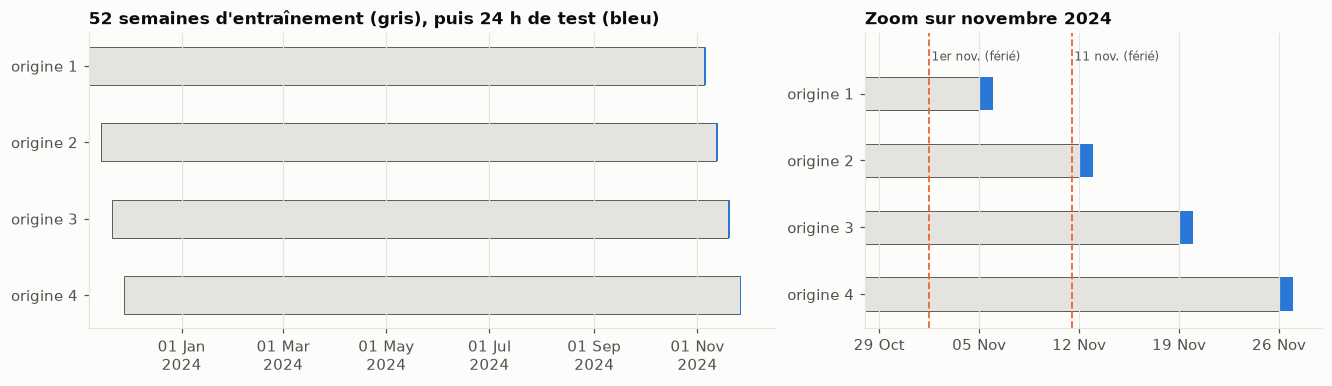

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4), layout="constrained", gridspec_kw={"width_ratios": [3, 2]})
for i, o in enumerate(ORIGINS):
    o = pd.Timestamp(o)
    start = o - pd.Timedelta(hours=spec.train_hours)
    for ax in axes:
        ax.barh(i, (o - start).days, left=start, height=0.5, color=viz.GRID, edgecolor=viz.TEXT_2, lw=0.6)
        ax.barh(i, 1, left=o, height=0.5, color=viz.BLUE)
axes[0].set_title("52 semaines d'entraînement (gris), puis 24 h de test (bleu)")
axes[1].set_xlim(pd.Timestamp("2024-10-28"), pd.Timestamp("2024-11-29"))
axes[1].set_title("Zoom sur novembre 2024")
for d, lbl in [("2024-11-01", "1er nov.\n(férié)"), ("2024-11-11", "11 nov.\n(férié)")]:
    axes[1].axvline(pd.Timestamp(d) + pd.Timedelta(hours=12), color=viz.ORANGE, lw=1.2, ls="--")
    axes[1].text(pd.Timestamp(d) + pd.Timedelta(hours=16), -0.45, lbl.replace("\n", " "), fontsize=8,
                 color=viz.TEXT_2, va="bottom")
for ax in axes:
    ax.set_yticks(range(len(ORIGINS)), [f"origine {i + 1}" for i in range(len(ORIGINS))])
    ax.invert_yaxis(); ax.grid(axis="y", visible=False)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b\n%Y" if ax is axes[0] else "%d %b"))
axes[1].xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.TU))
axes[1].set_ylim(3.5, -0.9)
export(fig, "protocole"); plt.show()

⚠️ **Point d'attention — « hors jours fériés » ne suffit pas.** Les origines ont été choisies un mardi pour que le
**jour prévu** ne soit pas férié. Mais la fenêtre d'entraînement de l'origine 2 (le 12 novembre) **se termine sur
un lundi férié**, le 11 novembre. Ce jour atypique est la dernière chose que voit le modèle. Le § 4 mesure son
effet.

## 2. Ce que fait chaque méthode, sur une origine

Toutes les méthodes partent des **mêmes** prévisions de base MSTL et renvoient des prévisions cohérentes. Elles ne
diffèrent que par la façon de répartir l'incohérence entre les séries, c'est-à-dire par W :

| Méthode | W | Qui bouge ? |
|---|---|---|
| BU (bottom-up) | — | seul le total : il est remplacé par la somme des régions |
| OLS | identité | toutes les séries, du même nombre de MW |
| WLS struct | diagonale, nombre de feuilles | le total bouge 12 fois plus que chaque région… en variance |
| WLS var | diagonale, variances des résidus | les séries aux résidus les plus grands bougent le plus |
| MinT shrink | pleine, résidus rétrécis | idem, en tenant compte des corrélations entre séries |

🧪 On mesure, à la première origine, l'**ajustement moyen** (prévision réconciliée − prévision de base) de chaque
série, en MW :

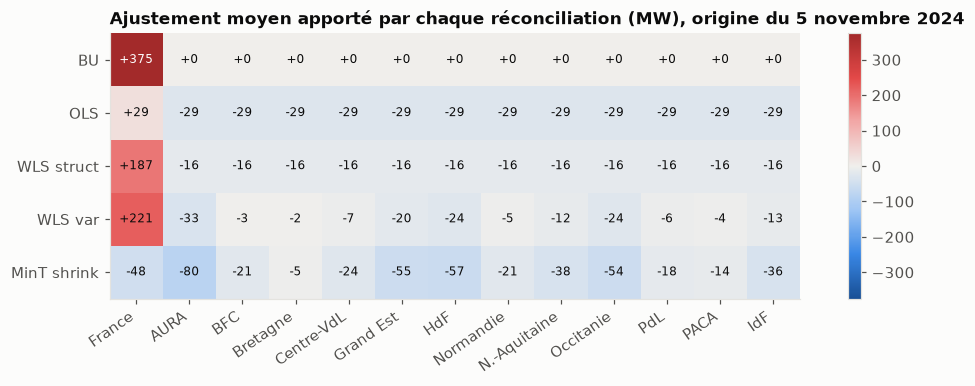

In [3]:
f0 = fc[fc["origin"] == ORIGINS[0]]
adj = pd.DataFrame({m: (to_wide(f0, order, m) - to_wide(f0, order, "base")).mean() for m in RECONCILED}).T
adj.columns = [prepare.short_name(c) for c in adj.columns]
fig, ax = plt.subplots(figsize=(12, 3.4), layout="constrained")
viz.heatmap(ax, adj.to_numpy(), list(adj.columns), list(adj.index), diverging=True, fmt="{:+.0f}",
            title="Ajustement moyen apporté par chaque réconciliation (MW), origine du 5 novembre 2024")
export(fig, "ajustements"); plt.show()

**Lecture.** La prévision de base du total est inférieure de 375 MW à la somme des régions (notebook 02, § 3).
Chaque méthode referme cet écart à sa façon :

- **BU** remonte le total de +375 MW et ne touche pas aux régions ;
- **OLS** coupe la poire en treize : +29 MW au total, −29 MW à chaque région, quelle que soit sa taille ;
- **WLS struct** et **WLS var** font porter l'essentiel au total (+187 et +221 MW). WLS var ajuste davantage les
  régions aux résidus les plus grands (AURA, HdF, Occitanie) ;
- **MinT shrink** fait l'inverse des autres : il **baisse** le total (−48 MW) et baisse toutes les régions
  davantage (environ −420 MW au total). Avec une W pleine, MinT tient compte des corrélations : il conclut que
  les prévisions régionales sont trop hautes **ensemble**, et corrige dans le même sens partout.

💡 **Ce qu'on attend de la comparaison.** La réconciliation ne crée pas d'information : elle redistribue celle
des 13 prévisions de base. Elle gagne si elle corrige surtout les séries les **moins fiables**, et perd si elle
se trompe sur qui est fiable. C'est exactement ce que W est censée dire.

## 3. Le tableau MASE × (niveau, méthode), avec écart-type entre origines

**Métrique** : MASE par série, puis par niveau (France ; moyenne des 12 régions). Le dénominateur est l'erreur
moyenne du naïf saisonnier (168 h) **sur le train de chaque origine**. Un MASE de 0,5 signifie : deux fois moins
d'erreur que répéter la semaine précédente, en moyenne sur l'historique.

**Deux baselines** : SN, le naïf saisonnier (si on ne le bat pas, rien d'autre ne compte), et BU, le bottom-up
sur les mêmes prévisions de base (la vraie baseline de réconciliation).

In [4]:
tol = float(cfg["inference"]["coherence_tol_abs"])
incoh = metrics.assert_coherent(fc, hier, RECONCILED, tol)          # échoue si le pipeline est cassé
print(f"Assertion de cohérence : OK, incohérence max après réconciliation = {incoh.to_numpy().max():.1e} MW (< {tol:g})")
print(f"Pour mémoire, incohérence max des prévisions de base MSTL : {metrics.incoherence(fc, hier, 'base').max():.0f} MW")

mase = metrics.mase_long(fc, scales, hier)
by_level = metrics.mase_by_level(mase)
table = metrics.summary_table(by_level, ["SN", "base", *RECONCILED])
display(table.style.format("{:.3f}").highlight_min(subset=["France mean", "Régions mean"], color="#cde2fb"))

Assertion de cohérence : OK, incohérence max après réconciliation = 0.0e+00 MW (< 1e-06)
Pour mémoire, incohérence max des prévisions de base MSTL : 672 MW


,France mean,France std,Régions mean,Régions std
method,,,,
SN,0.817,0.329,0.825,0.152
base,0.467,0.520,0.580,0.464
BU,0.500,0.607,0.580,0.464
OLS,0.469,0.527,0.544,0.388
WLS struct,0.481,0.564,0.560,0.423
WLS var,0.485,0.573,0.567,0.438
MinT shrink,0.463,0.507,0.542,0.383


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


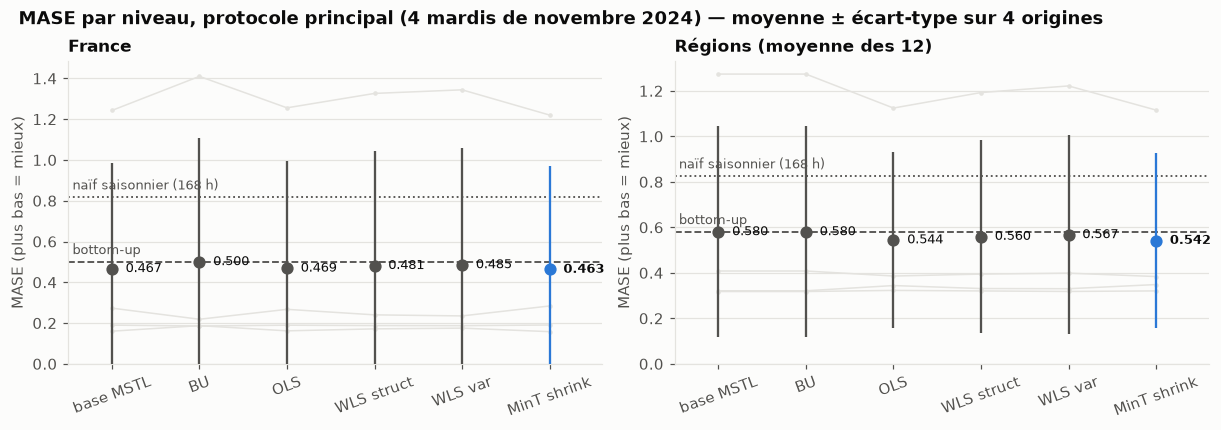

In [5]:
fig = figures.key_figure(by_level, "MASE par niveau, protocole principal (4 mardis de novembre 2024)")
plt.show()

In [6]:
per_origin = by_level.pivot_table(index=["level", "origin"], columns="method", values="mase")[["SN", "base", *RECONCILED]]
per_origin.index = per_origin.index.set_levels([pd.Index(per_origin.index.levels[0]),
                                                pd.to_datetime(per_origin.index.levels[1]).strftime("%d %b")])
display(per_origin.style.format("{:.3f}").highlight_min(axis=1, subset=RECONCILED, color="#cde2fb"))

**Lecture du tableau et de la figure.**

1. **MSTL bat le naïf saisonnier en moyenne**, aux deux niveaux : la baseline n°1 est franchie. Mais pas à
   toutes les origines : le 12 novembre, répéter la semaine précédente faisait **mieux** que MSTL.
2. **L'écart-type entre origines est énorme**, du même ordre que la moyenne. Les lignes grises de la figure
   montrent pourquoi : trois origines sont groupées vers 0,2–0,4, et **une seule, le 12 novembre**, est au-dessus
   de 1. La dispersion vient du **niveau d'erreur de l'origine**, pas du classement des méthodes : les lignes sont
   presque parallèles.
3. **Les écarts entre méthodes sont petits** devant cette dispersion. Le classement change d'une origine à
   l'autre (cellules surlignées du tableau par origine).

⚠️ **Point d'attention — moyenne ± écart-type n'est pas le bon résumé ici.** Avec 4 valeurs dont une aberrante,
la moyenne est tirée par le 12 novembre, et l'écart-type ne décrit ni les trois origines calmes ni l'origine
difficile. Pour **comparer deux méthodes**, ce qui compte n'est pas la dispersion de chacune, mais celle de leur
**différence**, origine par origine (§ 5).

## 4. Le 12 novembre : une origine qui écrase toutes les autres

Ce jour-là, la France consomme 55,5 GW en moyenne ; MSTL en prévoit 51,4. Deux explications sont possibles :

- **le lundi férié** (11 novembre) qui termine la fenêtre d'entraînement tire la tendance vers le bas ;
- **un choc extérieur aux séries** (le plus probable : un coup de froid), qu'aucun modèle sans météo ne peut voir.

🔬 **Test de la première explication, par contrefactuel.** On réentraîne MSTL sur la série France en remplaçant
le lundi 11 novembre par le lundi précédent (4 novembre), puis on compare l'erreur.

In [7]:
from statsforecast import StatsForecast
from statsforecast.models import MSTL
O2 = pd.Timestamp(ORIGINS[1])
tr, te = split_at(hier.Y_df, O2, spec)
fr, y = tr[tr["unique_id"] == "France"].copy(), te[te["unique_id"] == "France"]["y"].to_numpy()
def mstl(d):
    return StatsForecast(models=[MSTL(season_length=[24, 168])], freq="h").forecast(df=d, h=24)["MSTL"].to_numpy()
cf = fr.copy()
cf.loc[cf["ds"].dt.date == pd.Timestamp("2024-11-11").date(), "y"] = \
    fr.loc[fr["ds"].dt.date == pd.Timestamp("2024-11-04").date(), "y"].to_numpy()
f_real, f_cf = mstl(fr), mstl(cf)
mae_real, mae_cf = np.abs(y - f_real).mean(), np.abs(y - f_cf).mean()
display(pd.DataFrame({"prévision moyenne (MW)": [f_real.mean(), f_cf.mean(), y.mean()],
                      "MAE (MW)": [mae_real, mae_cf, np.nan]},
                     index=["MSTL, données réelles", "MSTL, 11 nov. remplacé par le 4 nov.", "réalisé"]).round(0))
print(f"part de l'erreur expliquée par le jour férié : {1 - mae_cf / mae_real:.0%}")

,prévision moyenne (MW),MAE (MW)
"MSTL, données réelles",51365.0,4162.0
"MSTL, 11 nov. remplacé par le 4 nov.",51796.0,3731.0
réalisé,55527.0,NaN


part de l'erreur expliquée par le jour férié : 10%


**Conclusion du test.** Le jour férié n'explique qu'une **petite part** de l'erreur. L'essentiel vient d'un saut
réel de la consommation, de l'ordre de +3,7 GW par rapport au mardi précédent.

🧪 **Un repère externe : la prévision J−1 de RTE.** Le jeu national publie la prévision de la veille de RTE, qui
utilise des prévisions météo. Ce n'est **pas** un concurrent équitable : elle dispose d'une information (la
météo) que nos modèles n'ont pas. Elle dit en revanche ce qui était prévisible.

,MSTL,BU,MinT shrink,RTE J−1
origin,,,,
Tue 05 Nov,0.27,0.22,0.28,0.20
Tue 12 Nov,1.24,1.41,1.22,0.34
Tue 19 Nov,0.16,0.19,0.16,0.58
Tue 26 Nov,0.19,0.19,0.19,0.25


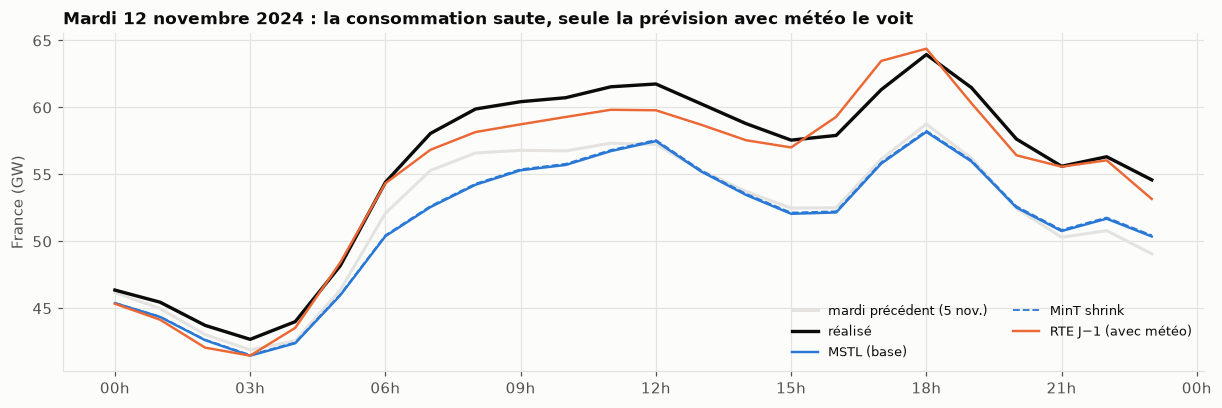

In [8]:
nat = pd.read_parquet(paths.interim / "national_hourly.parquet")
f_fr = fc[fc["unique_id"] == "France"].merge(nat[["rte_j1"]], left_on="ds", right_index=True)
sc_fr = scales[scales["unique_id"] == "France"].set_index("origin")["scale"]
rte = pd.DataFrame({m: f_fr.groupby("origin").apply(lambda g: np.abs(g["y"] - g[m]).mean()) / sc_fr
                    for m in ["base", "BU", "MinT shrink", "rte_j1"]})
rte.index = pd.to_datetime(rte.index).strftime("%a %d %b")
display(rte.rename(columns={"base": "MSTL", "rte_j1": "RTE J−1"}).style.format("{:.2f}")
        .set_caption("MASE au niveau France, par origine"))

g = f_fr[f_fr["origin"] == O2]
prev = hier.Y_df[(hier.Y_df["unique_id"] == "France") & hier.Y_df["ds"].between(O2 - pd.Timedelta(days=7), O2 - pd.Timedelta(days=6, hours=1))]
fig, ax = plt.subplots(figsize=(11, 3.6), layout="constrained")
ax.plot(g["ds"], prev["y"].to_numpy() / 1000, color=viz.GRID, lw=2, label="mardi précédent (5 nov.)")
ax.plot(g["ds"], g["y"] / 1000, color=viz.TEXT, lw=2.2, label="réalisé")
ax.plot(g["ds"], g["base"] / 1000, color=viz.BLUE, lw=1.6, label="MSTL (base)")
ax.plot(g["ds"], g["MinT shrink"] / 1000, color=viz.BLUE, lw=1.2, ls="--", label="MinT shrink")
ax.plot(g["ds"], g["rte_j1"] / 1000, color=viz.ORANGE, lw=1.6, label="RTE J−1 (avec météo)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Hh")); ax.set_ylabel("France (GW)")
ax.legend(loc="lower right", ncols=2, fontsize=8.5)
ax.set_title("Mardi 12 novembre 2024 : la consommation saute, seule la prévision avec météo le voit")
export(fig, "douze_novembre"); plt.show()

**Lecture.** Le 12 novembre, la prévision de RTE, qui intègre la météo, fait 3 à 4 fois moins d'erreur que
MSTL. Ce n'est pas une prévision uniformément meilleure : elle fait **moins bien** que MSTL les 19 et 26 novembre.
Son avantage est concentré sur le jour où la consommation saute. L'hypothèse d'un choc météorologique est donc la plus
plausible.

⚠️ **Point d'attention — hypothèse non vérifiée.** Ce jeu ne contient pas de températures : « coup de froid » est
une **inférence**, appuyée sur deux indices (le contrefactuel écarte le jour férié comme cause principale ; la
prévision avec météo voit le saut). Elle n'est pas démontrée ici.

📌 **Ce que cela dit de la réconciliation.** Aucune réconciliation ne rattrape une information que **aucune**
prévision de base ne contient. MinT redistribue l'erreur entre les séries ; il ne la fait pas disparaître
quand toutes les séries se trompent dans le même sens.

## 5. Le chiffre clé, et pourquoi 4 origines ne suffisent pas à conclure

Le plan demande **de combien MinT bouge le MASE au niveau régional**, le niveau qui porte la décision, par
rapport au bottom-up. On le calcule origine par origine, puis on teste si la différence est réelle.

In [9]:
k = metrics.key_figure(by_level, "MinT shrink", "BU")
display(pd.DataFrame(k).T.rename(columns={"mean": "variation moyenne", "std": "écart-type", "wins": "origines gagnées",
                                          "n_origins": "origines"})
        .style.format({"variation moyenne": "{:+.2%}", "écart-type": "{:.2%}", "min": "{:+.2%}", "max": "{:+.2%}",
                       "origines": "{:.0f}", "origines gagnées": "{:.0f}"}))
w = by_level[by_level["level"] == "Régions"].pivot(index="origin", columns="method", values="mase")
pc = inference.paired_comparison(w["MinT shrink"], w["BU"])
print(f"différence MinT − BU, régions : {pc['diff_mean']:+.4f} de MASE ; IC 95 % [{pc['ci95_low']:+.4f}, {pc['ci95_high']:+.4f}] ; "
      f"p (t apparié) = {pc['t_p']:.2f} ; n = {pc['n']}")

,variation moyenne,écart-type,min,max,origines,origines gagnées
Régions,-2.25%,9.01%,-12.43%,+8.56%,4,2
France,+0.81%,20.99%,-15.73%,+29.80%,4,2


différence MinT − BU, régions : -0.0381 de MASE ; IC 95 % [-0.1700, +0.0937] ; p (t apparié) = 0.43 ; n = 4


**Le chiffre clé du protocole principal.** Sur les 4 mardis de novembre, MinT shrink fait **baisser le MASE
régional d'environ 2 %** en moyenne par rapport au bottom-up, mais seulement à 2 origines sur 4, avec un
écart-type de 9 points.

🔬 **Le test dit qu'on ne peut pas conclure** : l'intervalle de confiance de la différence contient largement 0,
et le test de Wilcoxon n'est même pas calculable avec 4 paires. Avec 4 origines, un test t apparié a besoin
d'un effet énorme pour être significatif.

⚠️ **Point d'attention — le protocole de la Definition of Done mesure, il ne prouve pas.** 4 origines suffisent à
vérifier que le pipeline tourne, qu'il est cohérent et qu'il bat le naïf. Elles ne suffisent pas à classer des
méthodes dont les écarts sont de quelques pourcents. C'est pourquoi le protocole prévoit une **étude de
robustesse** sur toute l'année 2024 (notebook 04). Elle **renverse** le résultat ci-dessus.

📌 **À retenir — le protocole principal.**
- Le pipeline est **cohérent** (assertion < 1e-6 MW), et MSTL **bat le naïf saisonnier** aux deux niveaux.
- Toutes les réconciliations corrigent la même incohérence de base ; elles ne diffèrent que par **qui** elles
  ajustent, selon W.
- Une origine (le 12 novembre) domine tout : un **saut de consommation** que seule une prévision avec météo
  anticipe. Le jour férié précédent n'en explique qu'une petite part.
- Le chiffre clé (−2 % de MASE régional pour MinT) **n'est pas significatif** : 4 origines ne permettent pas de
  classer les méthodes.